In [ ]:
# install dependencies 
print("Installing dependencies...")
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import matplotlib.dates as mdates


import os 
from pathlib import Path
import warnings 
warnings.filterwarnings("ignore")

import logging
import sys
from pathlib import Path
from logging.handlers import RotatingFileHandler

def get_logger(
    name: str = __name__,
    log_file: str = "app.log",
    level: int = logging.DEBUG,
    max_bytes: int = 5 * 1024 * 1024,
    backup_count: int = 3
) -> logging.Logger:
    """
    Buat logger yang siap pakai dengan output ke console + file.

    Args:
        name        : nama logger, biasanya __name__ dari modul yang memanggil
        log_file    : path file log
        level       : minimum level yang direkam (default: DEBUG)
        max_bytes   : ukuran max per file log sebelum di-rotate (default: 5MB)
        backup_count: jumlah file backup yang disimpan

    Returns:
        logging.Logger
    """

    # Make sure log file exists
    Path(log_file).parent.mkdir(parents=True, exist_ok=True)

    logger = logging.getLogger(name)

    # Avoid duplicate handler, if handler exists, use the existing handler
    if logger.handlers:
        return logger

    logger.setLevel(level)

    # logging format
    fmt = logging.Formatter(
        fmt="%(asctime)s | %(levelname)-8s | %(name)s | %(filename)s:%(lineno)d | %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S"
    )

    # handler for console stdout
    console_handler = logging.StreamHandler(sys.stdout)
    console_handler.setLevel(logging.INFO)   # console: INFO ke atas saja
    console_handler.setFormatter(fmt)

    # handler for log file
    file_handler = RotatingFileHandler(
        log_file,
        maxBytes=max_bytes,
        backupCount=backup_count,
        encoding="utf-8"
    )
    file_handler.setLevel(logging.DEBUG)
    file_handler.setFormatter(fmt)

    logger.addHandler(console_handler)
    logger.addHandler(file_handler)

    return logger

# get root path of the project
PATH = Path(os.path.dirname(os.getcwd()))

print("All dependencies installed successfully!")
print(f"Current project directory: {PATH}")

Installing dependencies...
All dependencies installed successfully!
Current project directory: /Users/nadif/projects/hdi-recruitment


In [7]:
DATA_DIR = PATH / "data"
PROCESSED_DATA = DATA_DIR / "processed"

df = pd.read_csv(PROCESSED_DATA / "hdi_daily_ops_cleaned.csv", parse_dates=["date"])
print(f"{df.shape[0]} rows and {df.shape[1]} columns has been loaded.")
print(f"Dataset columns: {df.columns.to_list()}")
print(f"\nTop five data from dataset:\n{df.head()}")

1631 rows and 10 columns has been loaded.
Dataset columns: ['date', 'is_promo_period', 'day_of_week', 'new_enterpriser_count', 'new_bee_count', 'transaction_volume_online', 'transaction_volume_offline', 'sales_ep_thousand_idr', 'top_product_id', 'new_bee_count_outlier']

Top five data from dataset:
        date  is_promo_period day_of_week  new_enterpriser_count  \
0 2022-01-01                0    Saturday                    180   
1 2022-01-02                0      Sunday                    168   
2 2022-01-03                0      Monday                    100   
3 2022-01-04                0     Tuesday                    136   
4 2022-01-05                0   Wednesday                    149   

   new_bee_count  transaction_volume_online  transaction_volume_offline  \
0            511                       3442                        1871   
1            478                       4137                        1621   
2            284                       2609                       

In [16]:
# create some useful data from existing value to make statistical summary
df = df.copy()
df["total_new_registration"] = df["new_enterpriser_count"] + df["new_bee_count"]
df["total_transaction_volume"] = df["transaction_volume_online"] + df["transaction_volume_offline"]
df["transaction_online_pct"] = ((df["transaction_volume_online"] / df["total_transaction_volume"]) * 100).round(2)
df["transaction_offline_pct"] = ((df["transaction_volume_offline"] / df["total_transaction_volume"]) * 100).round(2)
df["sales_ep_million_idr"] = (df["sales_ep_thousand_idr"] / 1_000).round(2)
df["week"] = df["date"].dt.to_period("W")
df["year_week"] = df["date"].dt.strftime("%Y-W%U")

print(f"Current dataset:")
df.head()

Current dataset:


,date,is_promo_period,day_of_week,new_enterpriser_count,new_bee_count,transaction_volume_online,transaction_volume_offline,sales_ep_thousand_idr,top_product_id,new_bee_count_outlier,total_new_registration,total_transaction_volume,transaction_online_pct,transaction_offline_pct,week,year_week,sales_ep_million_idr
0,2022-01-01,0,Saturday,180,511,3442,1871,1018482,Protein E,0,691,5313,64.78,35.22,2021-12-27/2022-01-02,2022-W00,1018.48
1,2022-01-02,0,Sunday,168,478,4137,1621,1138112,Supplement A,0,646,5758,71.85,28.15,2021-12-27/2022-01-02,2022-W01,1138.11
2,2022-01-03,0,Monday,100,284,2609,1117,711536,Herbal D,0,384,3726,70.02,29.98,2022-01-03/2022-01-09,2022-W01,711.54
3,2022-01-04,0,Tuesday,136,387,2876,1611,939052,Supplement A,0,523,4487,64.10,35.90,2022-01-03/2022-01-09,2022-W01,939.05
4,2022-01-05,0,Wednesday,149,423,3327,1495,914561,Energy H,0,572,4822,69.00,31.00,2022-01-03/2022-01-09,2022-W01,914.56


In [120]:
date_min = df["date"].min().date()
date_max = df["date"].max().date()
total_days = len(df)
avg_daily_enterpriser = df["new_enterpriser_count"].mean()
max_daily_enterpriser = df["new_enterpriser_count"].max()
avg_daily_bee = df["new_bee_count"].mean()
avg_ep_sales_daily = df["sales_ep_million_idr"].mean()
avg_online_transaction_pct = df["transaction_online_pct"].mean()
promo_days_count = df["is_promo_period"].sum()
promo_days_pct = df["is_promo_period"].mean() * 100
avg_daily_enterpriser_promo = df[df["is_promo_period"] == 1]["new_enterpriser_count"].mean()
avg_daily_enterpriser_non_promo = df[df["is_promo_period"] == 0]["new_enterpriser_count"].mean()

print("=" * 63)
print(f"{"OPERATIONAL SUMMARY":>40}")
print("=" * 63)
print(f"Data range                          : {date_min} TO {date_max}")
print(f"Total days                          : {total_days:,}")
print(f"Average Daily New Enterpriser       : {avg_daily_enterpriser:.0f} per day (max {max_daily_enterpriser})")
print(f"Average Daily Ner Bee               : {avg_daily_bee:.0f} per day")
print(f"Average EP sales per day            : {avg_ep_sales_daily.round(2)}M per day")
print(f"Average Online Transaction %        : {avg_online_transaction_pct.round(1)}% per day")
print(f"Promo days total                    : {promo_days_count} ({promo_days_pct:.1f}% of days)")
print(f" - Avg enterpriser during PROMO     : {avg_daily_enterpriser_promo:.0f} per day")
print(f" - Avg enterpriser during NON PROMO : {avg_daily_enterpriser_non_promo:.0f} per day")


                     OPERATIONAL SUMMARY
Data range                          : 2022-01-01 TO 2026-06-19
Total days                          : 1,631
Average Daily New Enterpriser       : 223 per day (max 615)
Average Daily Ner Bee               : 632 per day
Average EP sales per day            : 1481.6M per day
Average Online Transaction %        : 69.1% per day
Promo days total                    : 546 (33.5% of days)
 - Avg enterpriser during PROMO     : 321 per day
 - Avg enterpriser during NON PROMO : 173 per day


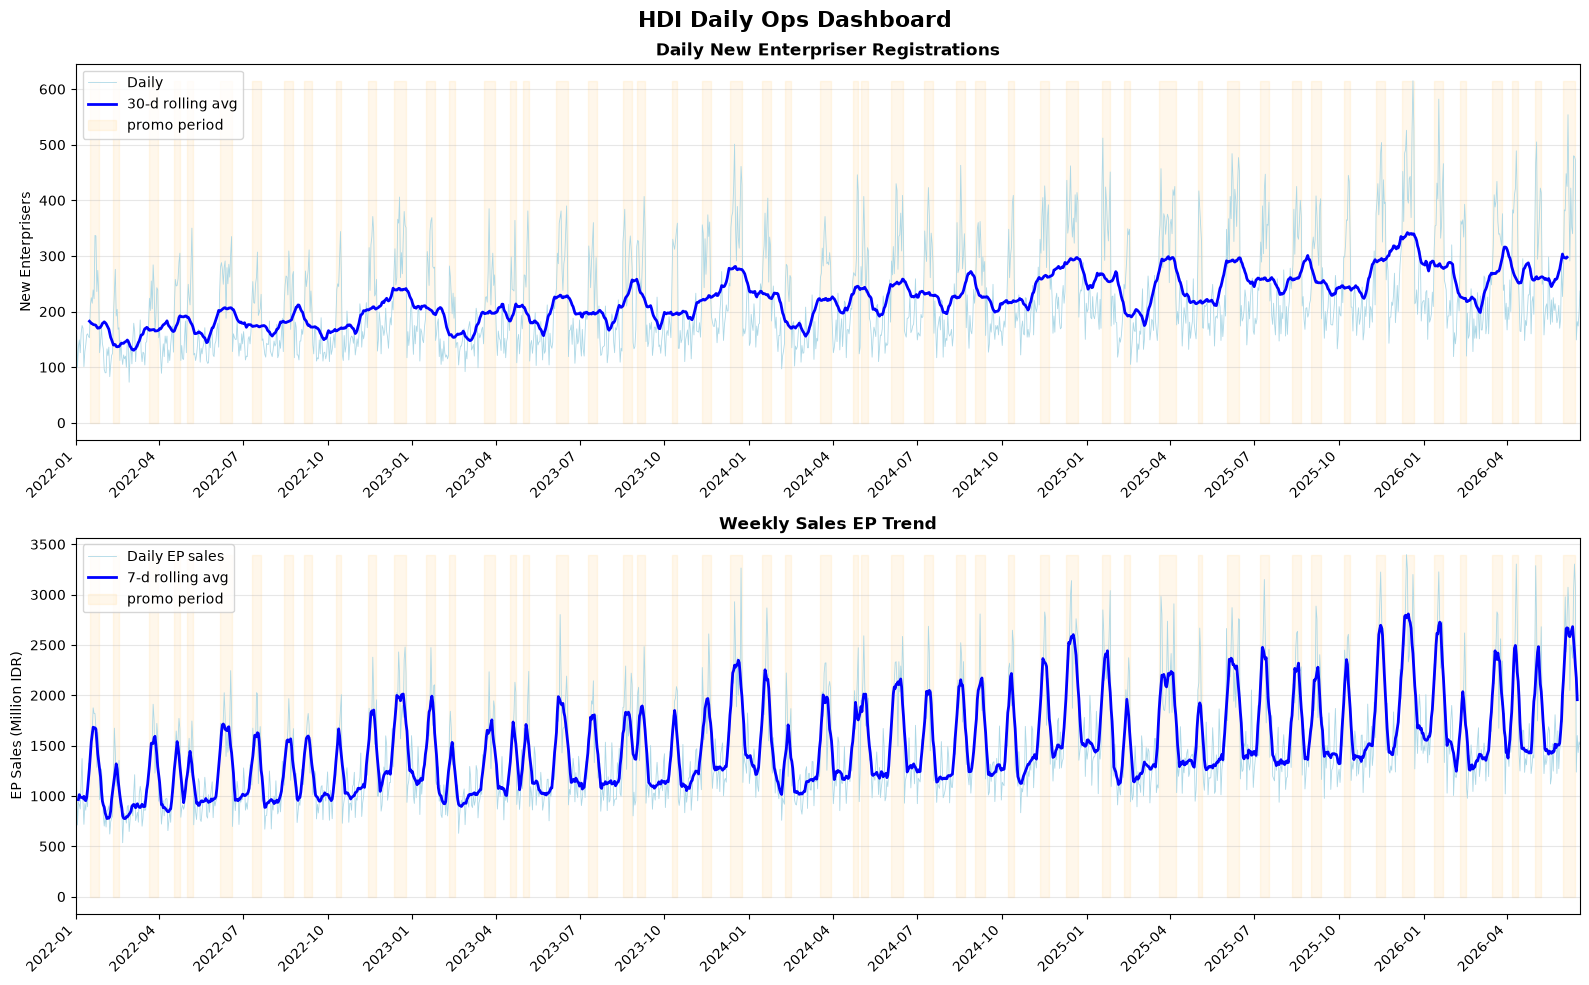

In [119]:
# Daily ops visualization

fig, axes = plt.subplots(2, 1, figsize=(16,10))
fig.suptitle("HDI Daily Ops Dashboard", fontweight="bold", fontsize=16)

# visualizing the new enterpriser count daily 
axes[0].plot(df["date"], df["new_enterpriser_count"], 
             color="lightblue", 
             alpha=1,
             linewidth=0.6,
             label="Daily",
             )

# visualizing monthly trend of new enterpriser count 
new_enterpriser_30d_rolling = df["new_enterpriser_count"].rolling(30, center=True).mean()
axes[0].plot(df["date"], new_enterpriser_30d_rolling,
             color="blue",
             linewidth=2,
             label="30-d rolling avg",
             )

# highlight promo period
promo_mask = df["is_promo_period"] == 1
axes[0].fill_between(df["date"], 0, df["new_enterpriser_count"].max(), 
                     where=promo_mask, 
                     alpha=0.08, 
                     color="orange", 
                     label="promo period",
                     )

# format the first graph
axes[0].set_title("Daily New Enterpriser Registrations", fontweight="bold")
axes[0].set_ylabel("New Enterprisers")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha="right")
axes[0].legend(loc="upper left")
axes[0].grid(axis="y", alpha=0.3)
axes[0].set_xlim(df['date'].min(), df['date'].max())

# visualize the weekly sales EP
axes[1].plot(df["date"], df["sales_ep_million_idr"], 
             color="lightblue", 
             alpha=1,
             linewidth=0.6,
             label="Daily EP sales",
             )

# visualizing monthly trend of new enterpriser count 
sales_ep_million_7d_rolling = df["sales_ep_million_idr"].rolling(7, center=True).mean()
axes[1].plot(df["date"], sales_ep_million_7d_rolling,
             color="blue",
             linewidth=2,
             label="7-d rolling avg",
             )

# highlight promo period
promo_mask = df["is_promo_period"] == 1
axes[1].fill_between(df["date"], 0, df["sales_ep_million_idr"].max(), 
                     where=promo_mask, 
                     alpha=0.08, 
                     color="orange", 
                     label="promo period",
                     )

# format the second graph
axes[1].set_title("Weekly Sales EP Trend", fontweight="bold")
axes[1].set_ylabel("EP Sales (Million IDR)")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha="right")
axes[1].legend(loc="upper left")
axes[1].grid(axis="y", alpha=0.3)
axes[1].set_xlim(df['date'].min(), df['date'].max())

plt.tight_layout()
plt.show()
